In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from pathlib import Path
from collections import defaultdict
import csv

# load model
model = YOLO("/home/debasish/Documents/YOLOv8/runs/pose/train4/weights/best.pt")

# best parameters (after optimization)
K_HEAD = 0
THETA = 45
THRESH = 0.24

# I/O
input_path = "/home/debasish/Documents/YOLOv8/videos/omega_turns/image052.mp4"
output_base_dir = Path("outputs/omega_turns")
output_base_dir.mkdir(parents=True, exist_ok=True)

VIDEO_EXTS = [".mp4", ".avi", ".mkv", ".mov"]

# create run folder to save outputs
def create_run_folder(base_dir):
    run_id = 1
    while (base_dir / f"run{run_id}").exists():
        run_id += 1
    run_dir = base_dir / f"run{run_id}"
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir

# angle
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians * 180 / np.pi)
    return 360 - angle if angle > 180 else angle

# end segment distances
def end_segment_distance(kpts, k=3):
    if len(kpts) < 2*k:
        return np.inf

    return min(
        np.linalg.norm(h - t)
        for h in kpts[:k]
        for t in kpts[-k:])

# process video
def process_video(video_path, run_dir):

    global time, frame_count

    video_name = Path(video_path).stem

    output_path = run_dir / f"{video_name}_omega.mp4"
    summary_path = run_dir / f"{video_name}_omega_counted.txt"
    framewise_csv = run_dir / f"{video_name}_framewise_turns.csv"

    cap = cv2.VideoCapture(str(video_path))

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if width == 0 or height == 0:
        print("[ERROR] Video not loaded properly")
        return

    fps = int(cap.get(cv2.CAP_PROP_FPS))
    

    out = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height))

    frame_count = 0

    omega_turns = defaultdict(int)
    last_state = defaultdict(lambda: "no_omega")
    all_worm_ids = set()

    colors = {}
    def get_color(worm_id):
        if worm_id not in colors:
            np.random.seed(int(worm_id))
            colors[worm_id] = tuple(np.random.randint(0, 255, 3).tolist())
        return colors[worm_id]

    # YOLO tracking
    results_gen = model.track(str(video_path),persist=True,tracker="bytetrack.yaml",stream=True,verbose=True)

    framewise_data = []

    for result in results_gen:
        frame_count += 1

        if result.orig_img is None:
            continue

        frame = result.orig_img.copy()
        current_frame_data = {}

        if result.boxes is None or result.keypoints is None:
            framewise_data.append(current_frame_data)
            out.write(frame)
            continue

        if result.boxes.id is None or result.keypoints.xy is None:
            framewise_data.append(current_frame_data)
            out.write(frame)
            continue

        ids = result.boxes.id.cpu().numpy()
        kpts_all = result.keypoints.xy.cpu().numpy()

        for i in range(len(ids)):
            track_id = int(ids[i])
            all_worm_ids.add(track_id)

            kpts = kpts_all[i]

            if len(kpts) < 6:
                continue

            head = kpts[K_HEAD]
            mid  = kpts[len(kpts)//2]
            tail = kpts[-1]

            angle = calculate_angle(head, mid, tail)

            seg_lengths = np.linalg.norm(np.diff(kpts, axis=0), axis=1)
            L = np.sum(seg_lengths)

            d = end_segment_distance(kpts)
            d_norm = d / L if L > 0 else np.inf

            # omega detection
            prev_state = last_state[track_id]
            
            # states
            if last_state[track_id] == "no_omega":
                if d_norm < THRESH and angle < THETA:
                    last_state[track_id] = "omega"
            
            elif last_state[track_id] == "omega":
                if d_norm > THRESH or angle > THETA:
                    last_state[track_id] = "no_omega"
            
            # update
            current_state = last_state[track_id]
            
            omega_flag = 1 if current_state == "omega" else 0
            
            # counting
            if prev_state == "no_omega" and current_state == "omega":
                omega_turns[track_id] += 1

            current_frame_data[track_id] = omega_flag

            # draw
            color = (0,255,0) if omega_flag else get_color(track_id)

            cv2.line(frame, tuple(head.astype(int)), tuple(mid.astype(int)), color, 2)
            cv2.line(frame, tuple(mid.astype(int)), tuple(tail.astype(int)), color, 2)

            cv2.putText(frame, f"ID:{track_id} ang:{int(angle)} turns:{omega_turns[track_id]}",
                (int(mid[0])+10, int(mid[1])-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        framewise_data.append(current_frame_data)
        out.write(frame)

    cap.release()
    out.release()

    # save framewise outputs
    all_worm_ids = sorted(list(all_worm_ids))

    time = frame_count/fps

    with open(framewise_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["frame"] + [f"worm_{wid}" for wid in all_worm_ids])

        for i, row in enumerate(framewise_data, start=1):
            writer.writerow([i] + [row.get(wid, 0) for wid in all_worm_ids])

    # save summary
    with open(summary_path, "w") as f:
        for wid in all_worm_ids:
            f.write(f"Worm {wid}: {omega_turns[wid]}\n")

    print(f"[INFO] Saved: {output_path}")

# main
input_path = Path(input_path)

if input_path.is_file() and input_path.suffix.lower() in VIDEO_EXTS:
    run_dir = create_run_folder(output_base_dir)
    process_video(input_path, run_dir)

elif input_path.is_dir():
    videos = [f for f in input_path.iterdir() if f.suffix.lower() in VIDEO_EXTS]

    run_dir = create_run_folder(output_base_dir)

    for v in videos:
        process_video(v, run_dir)

else:
    print(f"[ERROR] No valid video found at {input_path}")

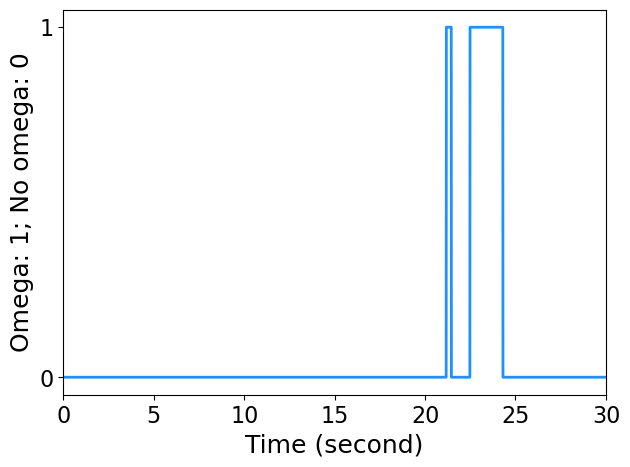

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/home/debasish/Documents/YOLOv8/outputs/omega_turns/run8/image047_framewise_turns.csv")
frame = df['frame'].to_list()
turns = df['worm_1'].to_list()

plt.figure(figsize=(7,5))
times = np.linspace(0,time,frame_count)

plt.plot(times, turns, color = 'dodgerblue', linewidth=2)
plt.xlim(0,30)
plt.xlabel('Time (second)',fontsize=18)
plt.ylabel('Omega: 1; No omega: 0', fontsize=18)
plt.yticks([0, 1])
plt.tick_params(axis='both', labelsize=16)
plt.show()